In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

# First Look

In [2]:
df = pd.read_csv('../data/raw/INMATE_ACTIVE_ROOT.txt', sep='\t', encoding='latin-1')
df.head()

,DCNumber,LastName,FirstName,MiddleName,NameSuffix,Race,Sex,BirthDate,PrisonReleaseDate,ReceiptDate,releasedateflag_descr,race_descr,custody_description,FACILITY_description
0,000132,TELFAIR,MICHAEL,NaN,NaN,B,M,12/04/1967,01/27/2033,10/08/2018,valid release date,BLACK,MINIMUM,MADISON C.I.
1,000155,LOCKETT,JERRY,I,NaN,B,M,09/26/1985,05/14/2026,05/23/2024,valid release date,BLACK,MEDIUM,GULF C.I.
2,000175,ELMORE,CHAD,R,NaN,W,M,10/20/1982,07/20/2028,06/11/2025,valid release date,WHITE,CLOSE,JACKSON C.I.
3,000191,CARRILLO,ISAIAS,NaN,JR,W,M,02/21/1998,03/30/2028,09/24/2025,valid release date,WHITE,MEDIUM,APALACHEE EAST UNIT
4,000203,RHINESMITH,AUSTIN,A,NaN,W,M,09/12/2000,09/06/2027,07/24/2025,valid release date,WHITE,MEDIUM,CFRC-EAST


In [3]:
df.shape

(90663, 14)

In [4]:
df.dtypes

DCNumber                 object
LastName                 object
FirstName                object
MiddleName               object
NameSuffix               object
Race                     object
Sex                      object
BirthDate                object
PrisonReleaseDate        object
ReceiptDate              object
releasedateflag_descr    object
race_descr               object
custody_description      object
FACILITY_description     object
dtype: object

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90663 entries, 0 to 90662
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   DCNumber               90663 non-null  object
 1   LastName               90662 non-null  object
 2   FirstName              90663 non-null  object
 3   MiddleName             69042 non-null  object
 4   NameSuffix             7413 non-null   object
 5   Race                   90663 non-null  object
 6   Sex                    90663 non-null  object
 7   BirthDate              90663 non-null  object
 8   PrisonReleaseDate      74745 non-null  object
 9   ReceiptDate            90663 non-null  object
 10  releasedateflag_descr  90663 non-null  object
 11  race_descr             90663 non-null  object
 12  custody_description    88358 non-null  object
 13  FACILITY_description   90663 non-null  object
dtypes: object(14)
memory usage: 9.7+ MB


# Missing Values

The heatmap below visualizes missing data across the dataset. Each column is represented on the x-axis, and each row in the dataset is represented on the y-axis. **Black indicates no missing value, white indicates a missing value.**

From the heatmap we can observe which columns have missing data and how that missingness is distributed across rows — for example, whether missing values tend to cluster together or appear randomly scattered.

In [6]:
# count missing values per column
df.isnull().sum()

DCNumber                     0
LastName                     1
FirstName                    0
MiddleName               21621
NameSuffix               83250
Race                         0
Sex                          0
BirthDate                    0
PrisonReleaseDate        15918
ReceiptDate                  0
releasedateflag_descr        0
race_descr                   0
custody_description       2305
FACILITY_description         0
dtype: int64

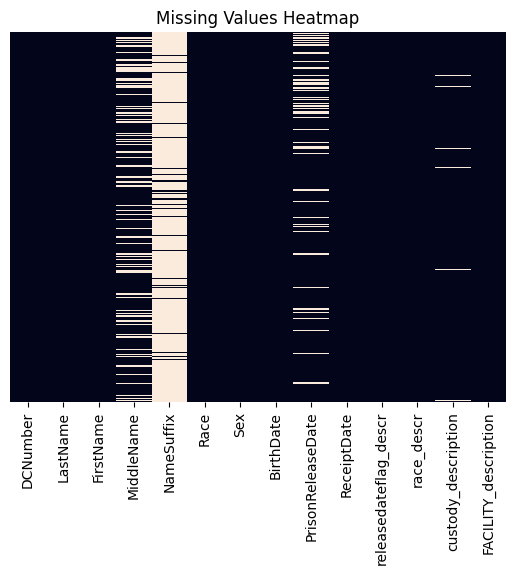

In [7]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()

The columns with the most missing values are **MiddleName** and **NameSuffix**. These are not considered critical for analysis — it is common for individuals to not have a middle name on record, and name suffixes (e.g. *Jr.*, *Sr.*, *II*, *III*) are even less common. These columns will be retained but excluded from analysis.

The next most commonly missing field is **PrisonReleaseDate**. This may indicate inmates who are serving life sentences or whose release date has not yet been determined. Further investigation is needed before deciding how to handle this.

A small number of rows are also missing **custody_description**. It is unclear at this stage whether this reflects a data entry issue or a legitimate unknown classification. This will be revisited during the cleaning phase.

# Demographics

This section explores the demographic composition of Florida's active inmate population,
including age, sex, and race. Visualizations and summary statistics are provided for each.

Note: Age is calculated as of today's date based on each inmate's recorded date of birth.

In [8]:
# calculate age from birth date and add as a new column
df['BirthDate'] = pd.to_datetime(df['BirthDate'])
df['Age'] = (pd.Timestamp.now() - df['BirthDate']).dt.days // 365 

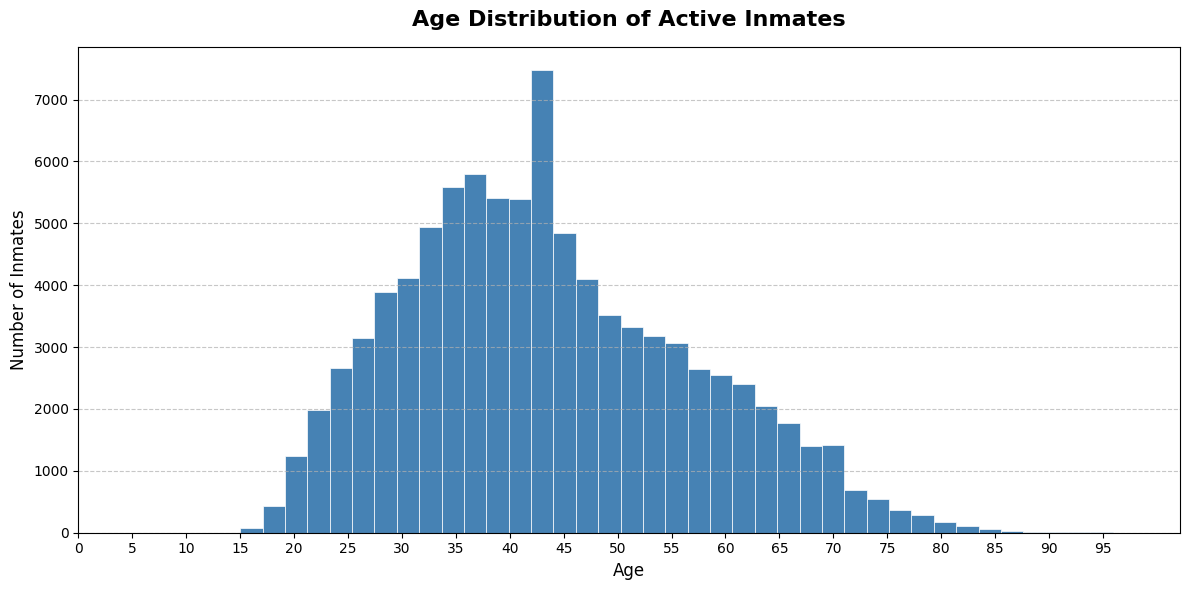

In [9]:
plt.figure(figsize=(12, 6))
plt.hist(df['Age'], bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Age Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(range(0, df['Age'].max()+1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
print("Age Stats:")
print(df['Age'].describe())

Age Stats:
count    90663.000000
mean        43.481045
std         13.234520
min         15.000000
25%         34.000000
50%         42.000000
75%         53.000000
max         98.000000
Name: Age, dtype: float64


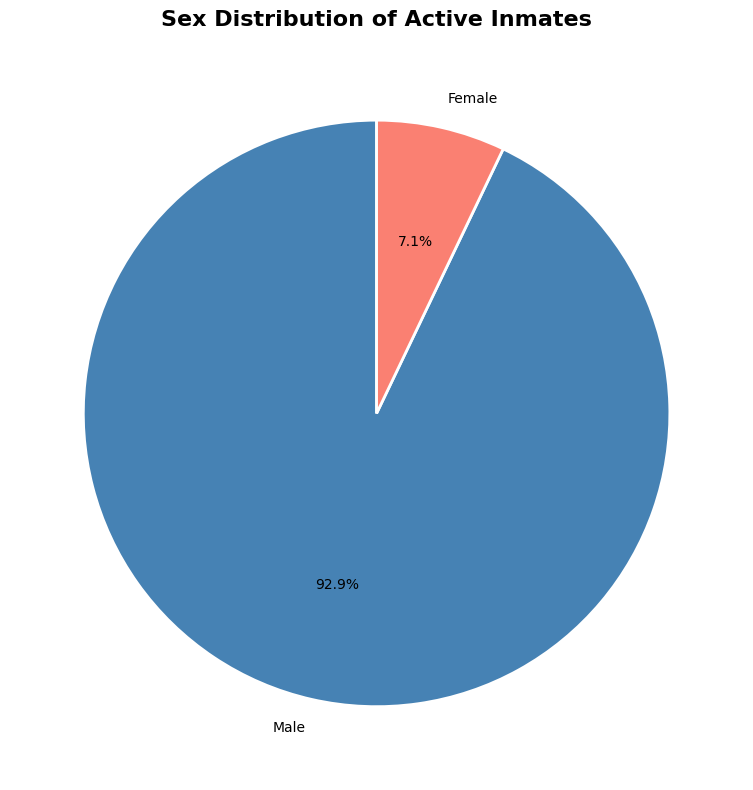

In [11]:
plt.figure(figsize=(8, 8))
sex_counts = df['Sex'].value_counts()
plt.pie(sex_counts, 
        labels=sex_counts.index.map({'M': 'Male', 'F': 'Female'}),
        autopct='%1.1f%%',
        colors=['steelblue', 'salmon'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title('Sex Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [12]:
print(df['Sex'].value_counts())
print(df['Sex'].value_counts(normalize=True) * 100)

Sex
M    84219
F     6444
Name: count, dtype: int64
Sex
M    92.89236
F     7.10764
Name: proportion, dtype: float64


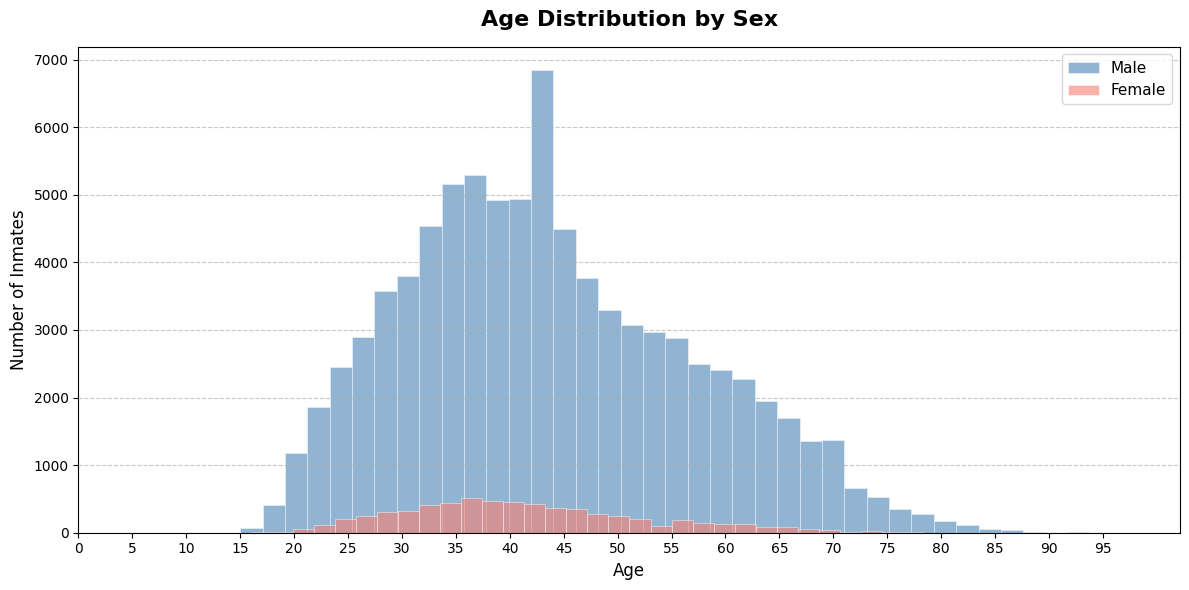

In [13]:
plt.figure(figsize=(12, 6))

male = df[df['Sex'] == 'M']['Age']
female = df[df['Sex'] == 'F']['Age']

plt.hist(male, bins=40, color='steelblue', edgecolor='white', linewidth=0.5, alpha=0.6, label='Male')
plt.hist(female, bins=40, color='salmon', edgecolor='white', linewidth=0.5, alpha=0.6, label='Female')

plt.title('Age Distribution by Sex', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(range(0, df['Age'].max()+1, 5), fontsize=10)
plt.yticks(fontsize=10)
plt.legend(fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
print("Male vs Female Age Stats:")
print(df.groupby('Sex')['Age'].describe())

Male vs Female Age Stats:
       count       mean        std   min   25%   50%   75%   max
Sex                                                             
F     6444.0  41.447083  11.466414  16.0  33.0  40.0  48.0  94.0
M    84219.0  43.636673  13.347473  15.0  34.0  42.0  53.0  98.0


In [15]:
df['race_descr'].unique()

array(['BLACK', 'WHITE', 'HISPANIC', 'ALL OTHERS/UNKNOWN',
       'AMERICAN INDIAN OR PACIFIC ISL', 'ASIAN OR PACIFIC ISLANDER'],
      dtype=object)

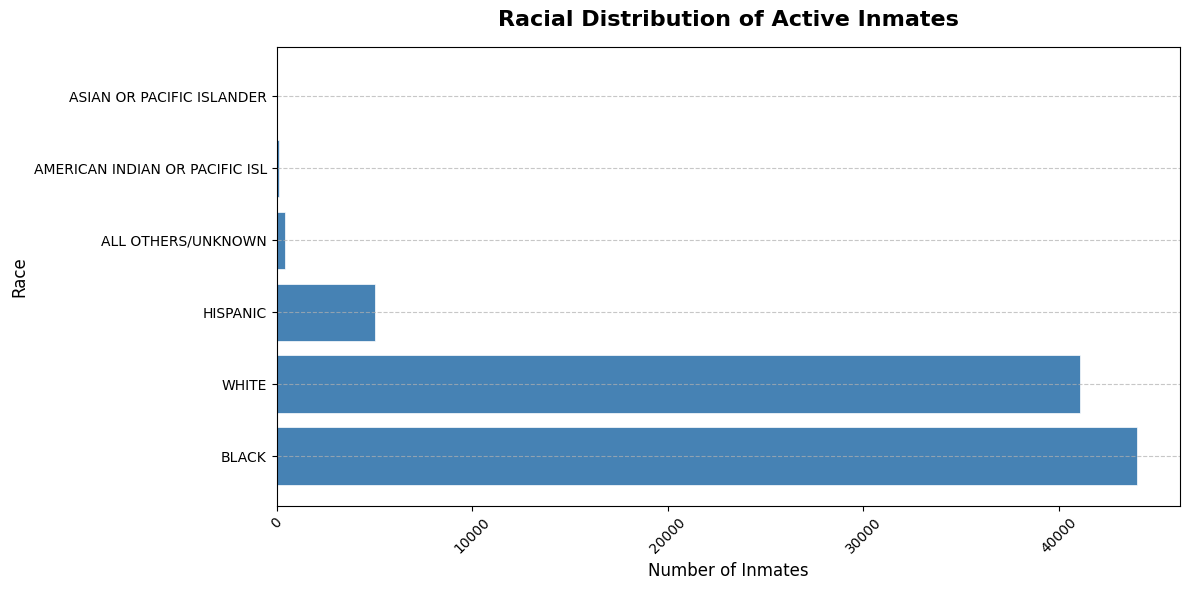

                                Count Percentage
race_descr                                      
BLACK                           44003     48.53%
WHITE                           41067      45.3%
HISPANIC                         5027      5.54%
ALL OTHERS/UNKNOWN                427      0.47%
AMERICAN INDIAN OR PACIFIC ISL    109      0.12%
ASIAN OR PACIFIC ISLANDER          30      0.03%


In [16]:
# Bar chart
race_counts = df['race_descr'].value_counts()

plt.figure(figsize=(12, 6))
plt.barh(race_counts.index, race_counts.values, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Racial Distribution of Active Inmates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Number of Inmates', fontsize=12)
plt.ylabel('Race', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Percentage table
race_pct = pd.DataFrame({
    'Count': race_counts,
    'Percentage': (race_counts / race_counts.sum() * 100).round(2).astype(str) + '%'
})
print(race_pct)

## Custody Levels

Inmates in the Florida DOC are assigned a custody level based on their assessed security
risk. The custody levels, from highest to lowest security, are:

- **MAXIMUM** — Highest security risk. Inmates require the most restrictive supervision
  and housing conditions.
- **CLOSE** — High security risk. Inmates are housed in secure facilities with strict
  supervision, one level below maximum.
- **MEDIUM** — Moderate security risk. Inmates are housed in standard correctional
  facilities with routine supervision.
- **MINIMUM** — Low security risk. Inmates may have more freedoms and privileges, and
  may be eligible for work release or other programs.
- **COMMUNITY** — Lowest security level. Inmates are typically in a transitional phase,
  potentially participating in community-based programs or work release in preparation
  for full reintegration.

In [17]:
# unique custody descriptions
custody_counts = df['custody_description'].value_counts()
custody_pct = pd.DataFrame({
    'Count': custody_counts,
    'Percentage': (custody_counts / custody_counts.sum() * 100).round(2).astype(str) + '%'
})
print(custody_pct)

# unique facilities
print("\nNumber of Unique Facilities: ", df['FACILITY_description'].nunique())

# ReceiptDate distribution
df['ReceiptDate'] = pd.to_datetime(df['ReceiptDate'])

                     Count Percentage
custody_description                  
CLOSE                44844     50.75%
MEDIUM               25836     29.24%
MINIMUM              12918     14.62%
COMMUNITY             4507       5.1%
MAXIMUM                253      0.29%

Number of Unique Facilities:  212


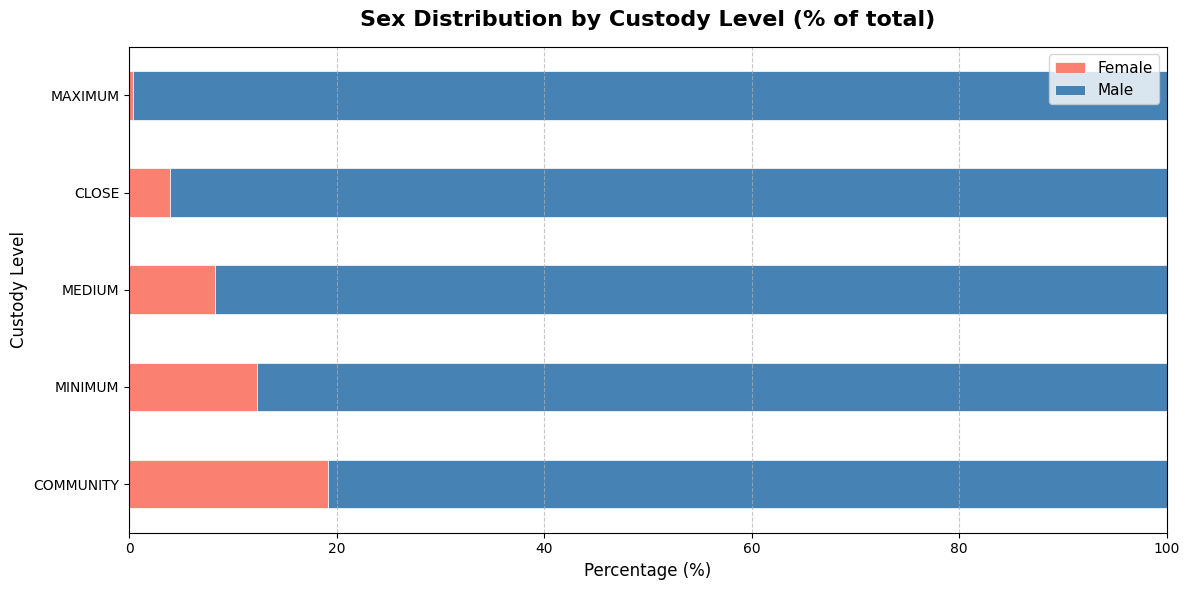

In [18]:
# Calculate counts by custody level and sex
custody_sex = df.groupby(['custody_description', 'Sex']).size().unstack(fill_value=0)

# Calculate percentages
custody_sex_pct = custody_sex.div(custody_sex.sum(axis=1), axis=0) * 100

# Reorder by security level (highest to lowest)
security_order = ['COMMUNITY', 'MINIMUM', 'MEDIUM', 'CLOSE', 'MAXIMUM']
custody_sex_pct = custody_sex_pct.reindex(security_order)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
custody_sex_pct.plot(
    kind='barh',
    stacked=True,
    color=['salmon', 'steelblue'],
    edgecolor='white',
    linewidth=0.5,
    ax=ax
)

ax.set_title('Sex Distribution by Custody Level (% of total)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Custody Level', fontsize=12)
ax.legend(['Female', 'Male'], fontsize=11)
ax.set_xlim(0, 100)
ax.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Sex Distribution by Custody Level

This chart shows the proportion of male and female inmates at each custody level,
normalized to 100% to account for the large overall disparity in the male/female
population (~93% male, ~7% female).

By normalizing, we can ask a more interesting question: **does the male/female ratio
vary meaningfully across security levels?** The answer is yes — there is a clear pattern:
female inmates make up their largest share of the population at the COMMUNITY level, and
their representation decreases steadily as security level increases. At the highest
security levels (CLOSE, MAXIMUM), females represent a much smaller proportion of the
population than their overall share would suggest.

This indicates that female inmates in Florida's DOC tend to be classified at lower security
levels, consistent with broader national trends in corrections research.

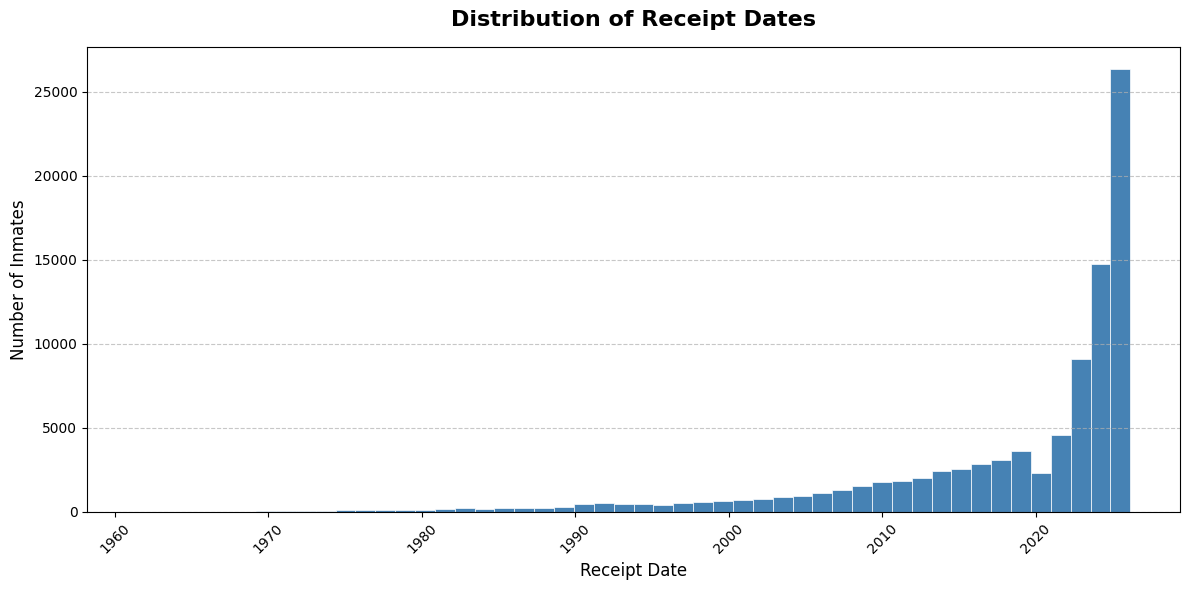

In [19]:
plt.figure(figsize=(12, 6))
plt.hist(df['ReceiptDate'], bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Receipt Dates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Receipt Date', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The distribution of receipt dates reveals several interesting trends in Florida's inmate population over time:

- **Pre-2005:** Admissions were slow and relatively steady.
- **2005–2020:** A noticeable and roughly linear increase in admissions, likely reflecting broader trends in criminal justice policy and  opulation growth.
- **2020:** A sharp drop in admissions, consistent with the COVID-19 pandemic, during which courts were backlogged and many jurisdictions reduced arrests and admissions.
- **Post-2020:** A dramatic spike in admissions following the pandemic drop. This may partly be due to the clearing of court backlogs rather.

This pattern is consistent with what many state prison systems experienced nationally during and after the COVID-19 pandemic. There is one important caveat to keep in mind here: the receipt dates are only for **active inmates**, meaning if an inmate was previously releasted, they wouldn't contribute any data to this figure. It's plausible that older inmates have already served time and been released. This could be another reason why more recent receipt dates are more highly represented than older dates.

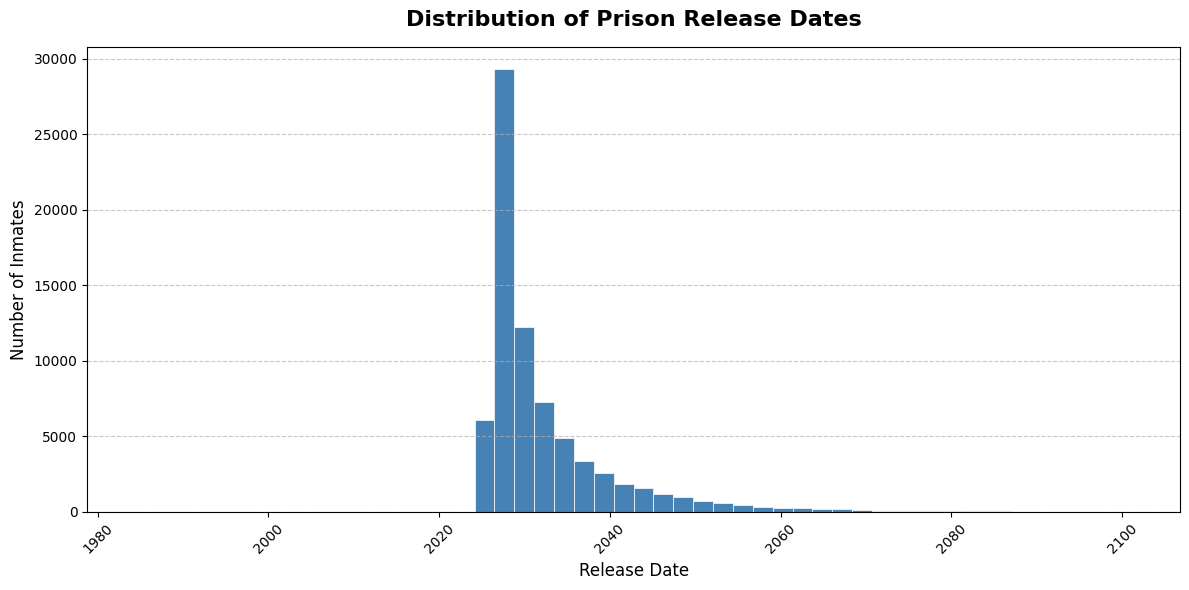

In [20]:
# drop null values; skip dates too far into the future
release_dates = df['PrisonReleaseDate'].dropna() 
release_dates = pd.to_datetime(release_dates, errors='coerce')
release_dates = release_dates[release_dates.dt.year <= 2100]  

plt.figure(figsize=(12, 6))
plt.hist(release_dates, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
plt.title('Distribution of Prison Release Dates', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Release Date', fontsize=12)
plt.ylabel('Number of Inmates', fontsize=12)
plt.xticks(fontsize=10, rotation=45)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [21]:
release_dates = df['PrisonReleaseDate'].dropna() 
release_dates = pd.to_datetime(release_dates, errors='coerce')

print("All Release Dates (including outliers):")
print(f"  Earliest: {release_dates.min()}")
print(f"  Latest:   {release_dates.max()}")
print(f"  Total with valid date: {release_dates.notna().sum()}")
print(f"  Outliers (year > 2100): {(release_dates.dt.year > 2100).sum()}")

release_dates_filtered = release_dates[release_dates.dt.year <= 2100]
print("\nFiltered Release Dates (year <= 2100):")
print(f"  Earliest: {release_dates_filtered.min()}")
print(f"  Latest:   {release_dates_filtered.max()}")
print(f"  Median:   {release_dates_filtered.median()}")
print(f"  Count:    {release_dates_filtered.count()}")

All Release Dates (including outliers):
  Earliest: 1984-08-04 00:00:00
  Latest:   2243-02-03 00:00:00
  Total with valid date: 74717
  Outliers (year > 2100): 92

Filtered Release Dates (year <= 2100):
  Earliest: 1984-08-04 00:00:00
  Latest:   2100-12-14 00:00:00
  Median:   2029-01-31 00:00:00
  Count:    74625


## Demographics Summary

The active inmate population of Florida's DOC is composed of **90,663 inmates** across
**212 facilities**. Key demographic findings:

- **Age:** The population skews middle-aged, with a median age of 42 and a mean of 43.
  Male inmates (median 42) tend to be slightly older than female inmates (median 40).
- **Sex:** The population is overwhelmingly male (~93%), with females comprising
  approximately 7% of active inmates.
- **Race:** Black and White inmates each make up similar shares of the population
  (~49% and ~45% respectively), with Hispanic inmates comprising ~6% and all other
  groups making up less than 1% combined.
- **Custody Level:** The majority of inmates are classified at the CLOSE (~51%) and
  MEDIUM (~29%) security levels. Female inmates are disproportionately represented at
  lower security levels (MINIMUM, COMMUNITY) relative to their overall share of the
  population, consistent with national trends in corrections.

Further visualizations and analysis will be presented in the Tableau dashboard.

# Adding Location Information

In [22]:
# see all unique facility names in the dataset
facilities = df['FACILITY_description'].value_counts().reset_index()
facilities.columns = ['FACILITY_description', 'count']
print(f"Total unique facilities: {len(facilities)}")
print(facilities)

Total unique facilities: 212
    FACILITY_description  count
0        BLACKWATER C.F.   1942
1         SOUTH BAY C.F.   1939
2        GRACEVILLE C.F.   1881
3        EVERGLADES C.I.   1842
4             UNION C.I.   1791
..                   ...    ...
207                 LEVY      1
208             ILLINOIS      1
209            HIGHLANDS      1
210              BREVARD      1
211                  LEE      1

[212 rows x 2 columns]


In [23]:
facilities['pct'] = (facilities['count'] / facilities['count'].sum() * 100).round(1)
facilities['cumulative_pct'] = facilities['pct'].cumsum().round(1)
print(facilities.head(100).to_string())

    FACILITY_description  count  pct  cumulative_pct
0        BLACKWATER C.F.   1942  2.1             2.1
1         SOUTH BAY C.F.   1939  2.1             4.2
2        GRACEVILLE C.F.   1881  2.1             6.3
3        EVERGLADES C.I.   1842  2.0             8.3
4             UNION C.I.   1791  2.0            10.3
5        OKEECHOBEE C.I.   1750  1.9            12.2
6           DESOTO ANNEX   1627  1.8            14.0
7              GULF C.I.   1586  1.7            15.7
8           LIBERTY C.I.   1543  1.7            17.4
9            MARTIN C.I.   1509  1.7            19.1
10           SUMTER C.I.   1506  1.7            20.8
11             DADE C.I.   1502  1.7            22.5
12       SANTA ROSA C.I.   1500  1.7            24.2
13           HARDEE C.I.   1499  1.7            25.9
14          WAKULLA C.I.   1478  1.6            27.5
15        COLUMBIA ANNEX   1467  1.6            29.1
16          CENTURY C.I.   1461  1.6            30.7
17     R.M.C.- MAIN UNIT   1450  1.6          

In [24]:
facility_city_map = {
    # Top 10
    'BLACKWATER C.F.': 'Milton',
    'SOUTH BAY C.F.': 'South Bay',
    'GRACEVILLE C.F.': 'Graceville',
    'EVERGLADES C.I.': 'Miami',
    'UNION C.I.': 'Raiford',
    'OKEECHOBEE C.I.': 'Okeechobee',
    'DESOTO ANNEX': 'Arcadia',
    'GULF C.I.': 'Wewahitchka',
    'LIBERTY C.I.': 'Bristol',
    'MARTIN C.I.': 'Indiantown',
    # 11-20
    'SUMTER C.I.': 'Bushnell',
    'DADE C.I.': 'Florida City',
    'SANTA ROSA C.I.': 'Milton',
    'HARDEE C.I.': 'Bowling Green',
    'WAKULLA C.I.': 'Crawfordville',
    'COLUMBIA ANNEX': 'Lake City',
    'CENTURY C.I.': 'Century',
    'R.M.C.- MAIN UNIT': 'Lake Butler',
    'SUWANNEE C.I. ANNEX': 'Live Oak',
    'LOWELL ANNEX': 'Ocala',
    # 21-30
    'FLORIDA STATE PRISON': 'Raiford',
    'HAMILTON ANNEX': 'Jasper',
    'MARION C.I.': 'Lowell',
    'NWFRC MAIN UNIT.': 'Chipley',
    'WALTON C.I.': 'DeFuniak Springs',
    'HOLMES C.I.': 'Bonifay',
    'MAYO C.I. ANNEX': 'Mayo',
    'JEFFERSON C.I.': 'Monticello',
    'CHARLOTTE C.I.': 'Punta Gorda',
    'SUWANNEE C.I': 'Live Oak',
    # 31-40
    'GADSDEN C.F.': 'Quincy',
    'POLK C.I.': 'Polk City',
    'MADISON C.I.': 'Madison',
    'TOMOKA C.I.': 'Daytona Beach',
    'CALHOUN C.I.': 'Blountstown',
    'JACKSON C.I.': 'Malone',
    'S.F.R.C.': 'Doral',
    'APALACHEE EAST UNIT': 'Sneads',
    'FRANKLIN C.I.': 'Carrabelle',
    'CROSS CITY C.I.': 'Cross City',
    # 41-50
    'CFRC-EAST': 'Orlando',
    'AVON PARK C.I.': 'Avon Park',
    'FL.WOMENS RECPN.CTR': 'Ocala',
    'COLUMBIA C.I.': 'Lake City',
    'SANTA ROSA ANNEX': 'Milton',
    'MOORE HAVEN C.F.': 'Moore Haven',
    'CFRC-MAIN': 'Orlando',
    'BAY C.F.': 'Panama City',
    'OKALOOSA C.I.': 'Crestview',
    'R.M.C.- WEST UNIT': 'Lake Butler',
    # 51-60
    'TAYLOR ANNEX': 'Perry',
    'LAKE CITY C.F.': 'Lake City',
    'WAKULLA ANNEX': 'Crawfordville',
    'NWFRC ANNEX.': 'Chipley',
    'TAYLOR C.I.': 'Perry',
    'LOWELL C.I.': 'Ocala',
    'LAWTEY C.I.': 'Lawtey',
    'HAMILTON C.I.': 'Jasper',
    'HOMESTEAD C.I.': 'Homestead',
    'APALACHEE WEST UNIT': 'Sneads',
    # 61-70
    'ZEPHYRHILLS C.I.': 'Zephyrhills',
    'LANCASTER C.I.': 'Trenton',
    'LAKE C.I.': 'Clermont',
    'AVON PARK WORK CAMP': 'Avon Park',
    'PUTNAM C.I.': 'East Palatka',
    'HERNANDO C.I.': 'Brooksville',
    'BAKER RE-ENTRY CENTR': 'Sanderson',
    'FSP WEST UNIT': 'Raiford',
    'S.F.R.C SOUTH UNIT': 'Doral',
    'GADSDEN RE-ENTRY CTR': 'Havana',
    # 71-80
    'EVERGLADES RE-ENTRY': 'Miami',
    'CROSS CITY EAST UNIT': 'Cross City',
    'QUINCY ANNEX': 'Quincy',
    'UNION WORK CAMP': 'Raiford',
    'SAGO PALM RE-ENTRY C': 'Clearwater',
    'HOLMES WORK CAMP': 'Bonifay',
    'LOWELL WORK CAMP': 'Ocala',
    'POLK WORK CAMP': 'Polk City',
    'DESOTO WORK CAMP': 'Arcadia',
    'LIBERTY SOUTH UNIT': 'Bristol',
    # 81-90
    'HARDEE WORK CAMP': 'Bowling Green',
    'GULF C.I.- ANNEX': 'Wewahitchka',
    'R.M.C WORK CAMP': 'Lake Butler',
    'OKALOOSA WORK CAMP': 'Crestview',
    'TOMOKA WORK CAMP': 'Daytona Beach',
    'LANCASTER W.C.': 'Trenton',
    'SUMTER WORK CAMP': 'Bushnell',
    'MADISON WORK CAMP': 'Madison',
    'MARION WORK CAMP': 'Lowell',
    'OKEECHOBEE WORK CAMP': 'Okeechobee',
    # 91-100
    'MARTIN WORK CAMP': 'Indiantown',
    'CROSS CITY WORK CAMP': 'Cross City',
    'JACKSON WORK CAMP': 'Malone',
    'SUNCOAST C.R.C.(FEM)': 'St. Petersburg',
    'CENTURY WORK CAMP': 'Century',
    'GAINESVILLE W.C.': 'Gainesville',
    'GRACEVILLE WORK CAMP': 'Graceville',
    'ST. PETE C.R.C.': 'St. Petersburg',
    'FEDERAL CUSTODY': None,
    'BAKER WORK CAMP': 'Sanderson',
}

# apply mapping
df['City'] = df['FACILITY_description'].map(facility_city_map)

# check coverage
mapped = df['City'].notna().sum()
print(f"Rows with city mapped: {mapped} ({mapped/len(df)*100:.1f}%)")
print(f"Rows without city: {df['City'].isna().sum()} ({df['City'].isna().sum()/len(df)*100.0:.1f}%)")

Rows with city mapped: 87509 (96.5%)
Rows without city: 3154 (3.5%)


# Facility Geocoding

To enable mapping of inmate populations by facility location in Tableau, a `City` column
was added to the dataset by manually mapping facility names to their corresponding cities.

The top 100 facilities by inmate count were mapped, accounting for approximately 97% of
the active inmate population. Inmates in facilities outside the top 100 — representing
the remaining ~3% — are assigned `NaN` for the `City` field, meaning they will not
appear on the map visualization.

The mapping was created using a combination of the Florida Department of Law Enforcement's
[Correctional Facilities Directory](https://www.fdle.state.fl.us/getContentAsset/93194699-a47c-4a62-96f1-323ec6b4818f/73aabf56-e6e5-4330-95a3-5f2a270a1d2b/Correctional-Facilities-Directory-PDF.pdf?language=en)
and Claude (Anthropic's AI assistant), which was used to cross-reference facility names
in the dataset against known facility locations. The resulting lookup dictionary maps
abbreviated facility names (e.g. `BLACKWATER C.F.`) to their corresponding cities
(e.g. `Milton`).

Note: `FEDERAL CUSTODY` was excluded from mapping as these inmates are not housed in
Florida state facilities and is also assigned `NaN`.

The `City` field can be used in Tableau to geocode facility locations and plot a bubble
map of Florida, with bubble size scaled by inmate count.

# Data Cleaning

In [25]:
# check for duplicate DC Numbers
duplicates = df[df.duplicated(subset='DCNumber', keep=False)]
print(f"Total rows with duplicate DC Numbers: {len(duplicates)}")
print(f"Number of duplicate DC Numbers: {df['DCNumber'].duplicated().sum()}")
print(f"\nSample of duplicates:")
print(duplicates.sort_values('DCNumber').head(10))

Total rows with duplicate DC Numbers: 0
Number of duplicate DC Numbers: 0

Sample of duplicates:
Empty DataFrame
Columns: [DCNumber, LastName, FirstName, MiddleName, NameSuffix, Race, Sex, BirthDate, PrisonReleaseDate, ReceiptDate, releasedateflag_descr, race_descr, custody_description, FACILITY_description, Age, City]
Index: []


In [26]:
# drop irrelevant columns
df = df.drop(columns=['MiddleName', 'NameSuffix'])
print("Dropped MiddleName and NameSuffix columns.")
print(f"Remaining columns: {list(df.columns)}")

Dropped MiddleName and NameSuffix columns.
Remaining columns: ['DCNumber', 'LastName', 'FirstName', 'Race', 'Sex', 'BirthDate', 'PrisonReleaseDate', 'ReceiptDate', 'releasedateflag_descr', 'race_descr', 'custody_description', 'FACILITY_description', 'Age', 'City']


In [27]:
# standardize date colums
df['BirthDate'] = pd.to_datetime(df['BirthDate'], errors='coerce')
df['ReceiptDate'] = pd.to_datetime(df['ReceiptDate'], errors='coerce')
df['PrisonReleaseDate'] = pd.to_datetime(df['PrisonReleaseDate'], errors='coerce')
print("Date columns converted to datetime.")
print(df[['BirthDate', 'ReceiptDate', 'PrisonReleaseDate']].dtypes)

Date columns converted to datetime.
BirthDate            datetime64[ns]
ReceiptDate          datetime64[ns]
PrisonReleaseDate    datetime64[ns]
dtype: object


In [28]:
# take a closer look at valid/invalid release dates
print("Release Date Flag Distribution:")
flag_counts = df['releasedateflag_descr'].value_counts(dropna=False)
flag_pct = pd.DataFrame({
    'Count': flag_counts,
    'Percentage': (flag_counts / flag_counts.sum() * 100).round(2).astype(str) + '%'
})
print(flag_pct)

Release Date Flag Distribution:
                                                    Count Percentage
releasedateflag_descr                                               
valid release date                                  74753     82.45%
life sentence                                       14769     16.29%
to be set                                             826      0.91%
death sentence                                        230      0.25%
pending                                                71      0.08%
coterminous Florida and other state/federal cus...     14      0.02%


In [29]:
total = len(df)
null_release = df[df['PrisonReleaseDate'].isnull()]
total_null = len(null_release)

# check overlap between null PrisonReleaseDate and invalid releasedateflag_descr
print("releasedateflag_descr values for rows WITH null PrisonReleaseDate:")
null_flags = null_release['releasedateflag_descr'].value_counts(dropna=False)
print(pd.DataFrame({
    'Count': null_flags,
    '% of Total Dataset': (null_flags / total * 100).round(1).astype(str) + '%',
    '% of Null Release Dates': (null_flags / total_null * 100).round(1).astype(str) + '%'
}))

print("\nreleasedateflag_descr values for rows WITHOUT null PrisonReleaseDate:")
valid_flags = df[df['PrisonReleaseDate'].notna()]['releasedateflag_descr'].value_counts(dropna=False)
print(pd.DataFrame({
    'Count': valid_flags,
    '% of Total Dataset': (valid_flags / total * 100).round(1).astype(str) + '%'
}))

releasedateflag_descr values for rows WITH null PrisonReleaseDate:
                       Count % of Total Dataset % of Null Release Dates
releasedateflag_descr                                                  
life sentence          14769              16.3%                   92.6%
to be set                826               0.9%                    5.2%
death sentence           230               0.3%                    1.4%
pending                   71               0.1%                    0.4%
valid release date        50               0.1%                    0.3%

releasedateflag_descr values for rows WITHOUT null PrisonReleaseDate:
                                                    Count % of Total Dataset
releasedateflag_descr                                                       
valid release date                                  74703              82.4%
coterminous Florida and other state/federal cus...     14               0.0%


In [30]:
# take a closer look at rows with null custody descriptions
null_custody = df[df['custody_description'].isnull()]
null_custody_percentage = len(null_custody)/len(df) * 100.0
print(f"Rows with null custody_description: {len(null_custody)} ({len(null_custody) / len(df) * 100:.1f}%)")
print("\nFacility breakdown for null custody rows:")
print(null_custody['FACILITY_description'].value_counts().head(10))

Rows with null custody_description: 2305 (2.5%)

Facility breakdown for null custody rows:
FACILITY_description
S.F.R.C.               603
CFRC-MAIN              447
CFRC-EAST              446
R.M.C.- MAIN UNIT      217
NWFRC ANNEX.           117
FEDERAL CUSTODY        111
R.M.C.- WEST UNIT       94
FL.WOMENS RECPN.CTR     78
CENTRAL OFFICE          36
GEORGIA                 13
Name: count, dtype: int64


In [31]:
# Flag release dates beyond year 2100 — likely reflect extremely long sentences
# (e.g. multiple consecutive charges) rather than data entry errors
extreme_dates = df[df['PrisonReleaseDate'].dt.year > 2100]
print(f"Rows with release date beyond 2100: {len(extreme_dates)}")
print(f"These likely represent inmates serving extremely long cumulative sentences.")
print(f"\nreleasedateflag_descr for these rows:")
print(extreme_dates['releasedateflag_descr'].value_counts(dropna=False))

Rows with release date beyond 2100: 92
These likely represent inmates serving extremely long cumulative sentences.

releasedateflag_descr for these rows:
releasedateflag_descr
valid release date    92
Name: count, dtype: int64


# Notebook Summary

This notebook performed exploratory data analysis and cleaning on the Florida Department
of Corrections active inmate dataset (`INMATE_ACTIVE_ROOT.txt`), which contains records
for **90,663 active inmates** across **212 facilities**.

## Key Findings

- **Demographics:** The population is predominantly male (~93%), middle-aged (median age
  42), and roughly evenly split between Black (~49%) and White (~45%) inmates, with
  Hispanic inmates comprising ~6%.
- **Custody:** The majority of inmates are classified at CLOSE (~51%) or MEDIUM (~29%)
  security levels. Female inmates are disproportionately represented at lower security
  levels relative to their share of the overall population.
- **Release Dates:** ~17.5% of inmates have no recorded release date. This is not a data
  quality issue — the vast majority (~93%) of these are inmates serving life sentences,
  death sentences, or with pending classifications.
- **Receipt Dates:** The dataset reflects a recency bias — recent receipt dates are
  overrepresented because older inmates have had more time to be released and exit the
  active population.

## Data Cleaning Steps

- Dropped `MiddleName` and `NameSuffix` (high missingness, low value)
- Converted all date columns to datetime
- Retained rows with null release dates and custody descriptions as missingness is meaningful

## Next Steps

The cleaned dataset has been exported to `data/processed/inmate_active_clean.csv`
and will be used to build a Tableau dashboard with further visualizations.

In [32]:
df.to_csv('../data/processed/inmate_active_clean.csv', index=False)
print(f"Cleaned dataset exported. Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

Cleaned dataset exported. Shape: (90663, 14)
Columns: ['DCNumber', 'LastName', 'FirstName', 'Race', 'Sex', 'BirthDate', 'PrisonReleaseDate', 'ReceiptDate', 'releasedateflag_descr', 'race_descr', 'custody_description', 'FACILITY_description', 'Age', 'City']
